# Trainig Notebook
Imports  Libraries

In [ ]:
import json
import shutil
import zipfile
import time
from pathlib import Path

In [ ]:
import numpy as np

In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report,
)

## Mount Drive in Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Bring the dataset zip from Drive to the local runtime disk and unzip there.
# Local disk I/O is much faster than reading thousands of files over mounted

In [ ]:
DRIVE_ZIP = Path("/content/drive/MyDrive/hardware-store/ETL/hardware_store_224.zip")
LOCAL_DATA_ROOT = Path("/content/hardware_store_224")

In [ ]:
if LOCAL_DATA_ROOT.exists():
    shutil.rmtree(LOCAL_DATA_ROOT)
LOCAL_DATA_ROOT.mkdir(parents=True)


In [ ]:
with zipfile.ZipFile(DRIVE_ZIP, "r") as zf:
    zf.extractall(LOCAL_DATA_ROOT)


In [ ]:
print("Extracted. Top-level contents:")
for p in sorted(LOCAL_DATA_ROOT.iterdir()):
    print(" -", p.name)

Extracted. Top-level contents:
 - classes.json
 - processed_manifest.json
 - train
 - val


In [ ]:
TRAIN_DIR = LOCAL_DATA_ROOT / "train"
VAL_DIR = LOCAL_DATA_ROOT / "val"

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [ ]:
BATCH_SIZE = 256          # MobileNetV3-Large is small
NUM_WORKERS = 4
MAX_EPOCHS = 30
LEARNING_RATE = 7.5e-4
WEIGHT_DECAY = 1.5e-4
WEIGHT_POWER = 0.56

In [ ]:
EARLY_STOP_PATIENCE = 5   # epochs without val macro-F1 improvement before stopping

In [ ]:
OUTPUT_DIR = Path("/content/training_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Transforms. Images are already 224x224 from the ETL,

The only train-time augmentation is a horizontal flip - a hammer flipped is
still a hammer. Remove it if any class is handedness-sensitive.


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = ImageFolder(VAL_DIR, transform=val_transform)

In [ ]:
num_classes = len(train_dataset.classes)
print(f"Classes: {num_classes}")
print(f"Train images: {len(train_dataset)}")
print(f"Val images:   {len(val_dataset)}")

Classes: 87
Train images: 54735
Val images:   9655


In [ ]:
# Guard: train and val must share the same class ordering.
assert train_dataset.classes == val_dataset.classes, "Class mismatch between splits"


## Persist the index-to-label mapping immediately.
The ONNX model outputs a class index; the Java backend needs this exact map
to turn an index into a tool name.

ImageFolder assigns indices alphabetically.


In [ ]:
idx_to_class = {idx: cls for cls, idx in train_dataset.class_to_idx.items()}


In [ ]:
with open(OUTPUT_DIR / "idx_to_class.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)


In [ ]:
print("Saved idx_to_class.json")
print("First few:", {k: idx_to_class[k] for k in list(idx_to_class)[:5]})


Saved idx_to_class.json
First few: {0: 'air_compressors', 1: 'angle_grinder', 2: 'axe_ai', 3: 'ball_valve', 4: 'bearing'}


# Class weights: softened inverse frequency.
Raw inverse frequency (power 1.0) over-corrects an 8x imbalance.

In [ ]:
train_targets = np.array(train_dataset.targets)
class_counts = np.bincount(train_targets, minlength=num_classes).astype(np.float64)


In [ ]:
raw_weights = (1.0 / class_counts) ** WEIGHT_POWER
class_weights = raw_weights / raw_weights.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

In [ ]:
print(f"Weight power: {WEIGHT_POWER}")
print(f"Max/min weight ratio: {class_weights.max() / class_weights.min():.2f}x")
print(f"Heaviest class: {idx_to_class[int(class_weights.argmax())]} "
      f"(w={class_weights.max():.2f})")
print(f"Lightest class: {idx_to_class[int(class_weights.argmin())]} "
      f"(w={class_weights.min():.2f})")


Weight power: 0.56
Max/min weight ratio: 3.30x
Heaviest class: paint_spray_gun (w=1.99)
Lightest class: tape_measure (w=0.60)


In [ ]:
# DataLoaders. pin_memory + workers keep the A100 fed.

In [ ]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    persistent_workers=True,
)

In [ ]:
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True,
)

##  Model: MobileNetV3-Large with the improved IMAGENET1K_V2 weights.
Replace only the final classifier Linear (1280 -> num_classes).


In [ ]:
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
model = mobilenet_v3_large(weights=weights)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 94.6MB/s]


In [ ]:
model = model.to(device, memory_format=torch.channels_last)

In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Trainable parameters: 4,313,479


## Loss, optimizer, scheduler, AMP scaler.
CrossEntropy carries the softened class weights. AdamW + cosine annealing over
the full epoch budget. Mixed precision (AMP) roughly halves memory and speeds up the A100, which is the main lever for spending fewer GPU credits.

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
scaler = torch.amp.GradScaler("cuda")

## Metric helpers.

In [ ]:

def compute_epoch_metrics(all_logits: np.ndarray, all_labels: np.ndarray) -> dict:
    """Top-1, Top-3, and macro-F1 from raw logits and integer labels."""
    top1_preds = all_logits.argmax(axis=1)
    top1 = (top1_preds == all_labels).mean()

    top3_idx = np.argsort(all_logits, axis=1)[:, -3:]
    top3 = np.mean([label in row for label, row in zip(all_labels, top3_idx)])

    macro_f1 = f1_score(all_labels, top1_preds, average="macro", zero_division=0)
    return {"top1": float(top1), "top3": float(top3), "macro_f1": float(macro_f1)}


In [ ]:

# Training and validation loops.

def run_train_epoch() -> float:
    model.train()
    running_loss = 0.0
    seen = 0
    for images, labels in train_loader:
        images = images.to(device, memory_format=torch.channels_last, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        seen += images.size(0)
    return running_loss / seen


In [ ]:

@torch.no_grad()
def run_val_epoch() -> tuple:
    model.eval()
    running_loss = 0.0
    seen = 0
    logits_buffer = []
    labels_buffer = []
    for images, labels in val_loader:
        images = images.to(device, memory_format=torch.channels_last, non_blocking=True)
        labels_gpu = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss = criterion(logits, labels_gpu)

        running_loss += loss.item() * images.size(0)
        seen += images.size(0)
        logits_buffer.append(logits.float().cpu().numpy())
        labels_buffer.append(labels.numpy())

    val_loss = running_loss / seen
    all_logits = np.concatenate(logits_buffer)
    all_labels = np.concatenate(labels_buffer)
    return val_loss, all_logits, all_labels


## Main training loop with early stopping on val macro-F1 and best-checkpoint save.
Early stopping is aaply in order to save GPU hours

In [ ]:
history = {
    "train_loss": [], "val_loss": [],
    "val_top1": [], "val_top3": [], "val_macro_f1": [], "lr": [],
}

In [ ]:
BEST_CKPT_PATH = OUTPUT_DIR / "best_model.pt"
best_macro_f1 = -1.0
epochs_no_improve = 0

In [ ]:

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    train_loss = run_train_epoch()
    val_loss, val_logits, val_labels = run_val_epoch()
    metrics = compute_epoch_metrics(val_logits, val_labels)
    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_top1"].append(metrics["top1"])
    history["val_top3"].append(metrics["top3"])
    history["val_macro_f1"].append(metrics["macro_f1"])
    history["lr"].append(current_lr)

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | {dt:5.1f}s | "
          f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
          f"top1 {metrics['top1']:.4f} | top3 {metrics['top3']:.4f} | "
          f"macroF1 {metrics['macro_f1']:.4f}")

    if metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = metrics["macro_f1"]
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT_PATH)
        print(f"  new best macro-F1 {best_macro_f1:.4f} - checkpoint saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"  early stopping at epoch {epoch} "
                  f"(no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break


Epoch 01/30 |  60.9s | train_loss 0.6975 | val_loss 0.4013 | top1 0.8850 | top3 0.9640 | macroF1 0.8749
  new best macro-F1 0.8749 - checkpoint saved
Epoch 02/30 |  30.8s | train_loss 0.2001 | val_loss 0.3670 | top1 0.8969 | top3 0.9711 | macroF1 0.8871
  new best macro-F1 0.8871 - checkpoint saved
Epoch 03/30 |  30.4s | train_loss 0.1312 | val_loss 0.3561 | top1 0.9018 | top3 0.9719 | macroF1 0.8906
  new best macro-F1 0.8906 - checkpoint saved
Epoch 04/30 |  30.2s | train_loss 0.0951 | val_loss 0.3271 | top1 0.9093 | top3 0.9748 | macroF1 0.8987
  new best macro-F1 0.8987 - checkpoint saved
Epoch 05/30 |  30.6s | train_loss 0.0792 | val_loss 0.3298 | top1 0.9131 | top3 0.9759 | macroF1 0.9058
  new best macro-F1 0.9058 - checkpoint saved
Epoch 06/30 |  30.3s | train_loss 0.0620 | val_loss 0.3315 | top1 0.9154 | top3 0.9771 | macroF1 0.9083
  new best macro-F1 0.9083 - checkpoint saved
Epoch 07/30 |  29.8s | train_loss 0.0557 | val_loss 0.3346 | top1 0.9164 | top3 0.9773 | macroF1 0.9

In [ ]:
print(f"Best val macro-F1: {best_macro_f1:.4f}")

Best val macro-F1: 0.9397


In [ ]:
# Save the training history as JSON.

with open(OUTPUT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved history.json")

Saved history.json


In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

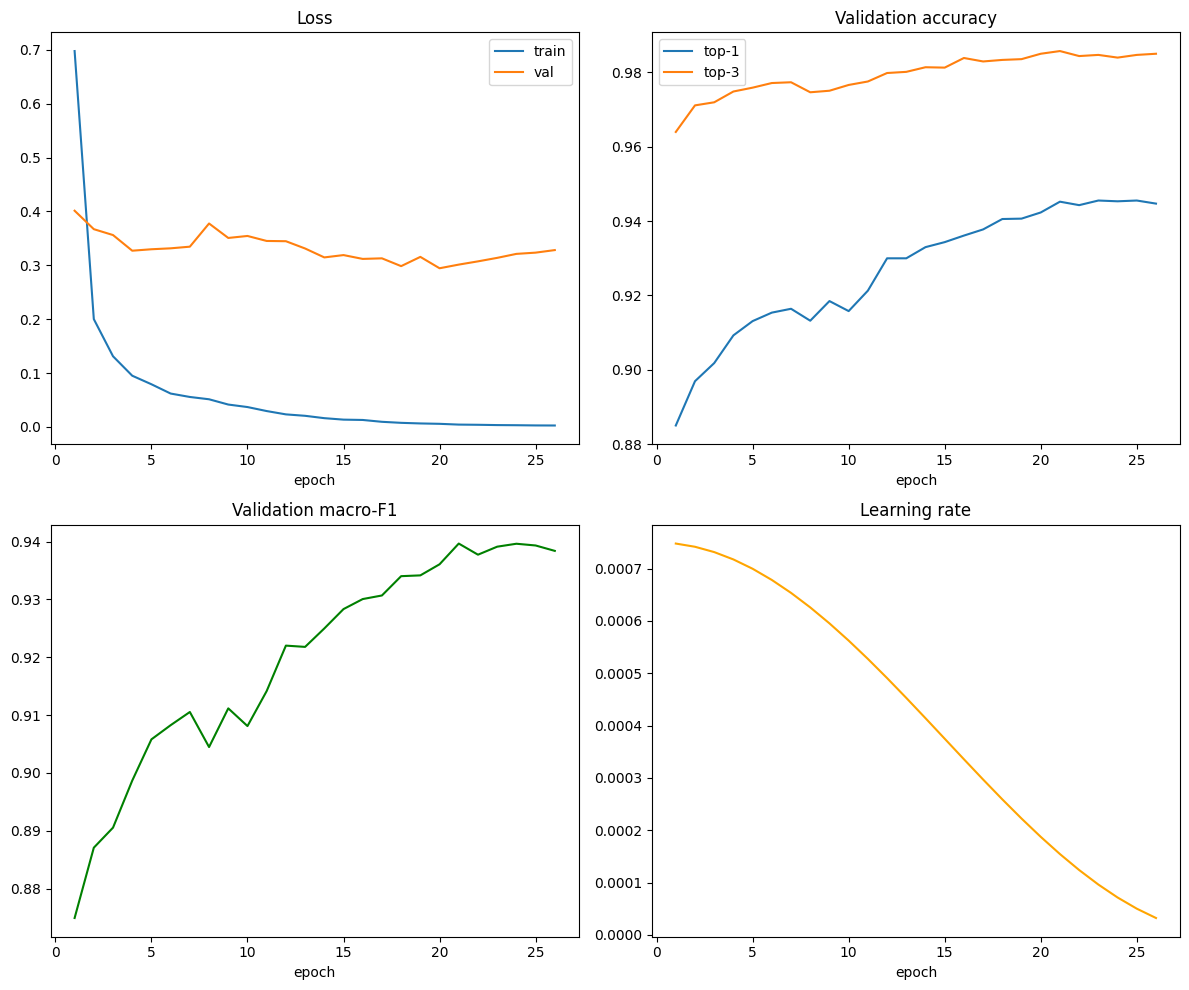

Saved training_curves.png


In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(epochs_ran, history["train_loss"], label="train")
axes[0, 0].plot(epochs_ran, history["val_loss"], label="val")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend()

axes[0, 1].plot(epochs_ran, history["val_top1"], label="top-1")
axes[0, 1].plot(epochs_ran, history["val_top3"], label="top-3")
axes[0, 1].set_title("Validation accuracy")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].legend()

axes[1, 0].plot(epochs_ran, history["val_macro_f1"], color="green")
axes[1, 0].set_title("Validation macro-F1")
axes[1, 0].set_xlabel("epoch")

axes[1, 1].plot(epochs_ran, history["lr"], color="orange")
axes[1, 1].set_title("Learning rate")
axes[1, 1].set_xlabel("epoch")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")


## Reload the best checkpoint for the final detailed evaluation.

In [ ]:
model.load_state_dict(torch.load(BEST_CKPT_PATH))
val_loss, val_logits, val_labels = run_val_epoch()
val_preds = val_logits.argmax(axis=1)

In [ ]:
class_names = [idx_to_class[i] for i in range(num_classes)]

Full metric report on the best model.
Weighted and macro precision/recall/F1, plus top-1 and top-3.


In [ ]:

prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    val_labels, val_preds, average="weighted", zero_division=0)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    val_labels, val_preds, average="macro", zero_division=0)


In [ ]:
final_metrics = compute_epoch_metrics(val_logits, val_labels)

In [ ]:
report = {
    "top1_accuracy": final_metrics["top1"],
    "top3_accuracy": final_metrics["top3"],
    "precision_weighted": float(prec_w),
    "recall_weighted": float(rec_w),
    "f1_weighted": float(f1_w),
    "precision_macro": float(prec_m),
    "recall_macro": float(rec_m),
    "f1_macro": float(f1_m),
}

In [ ]:

print(json.dumps(report, indent=2))

{
  "top1_accuracy": 0.9452097358881408,
  "top3_accuracy": 0.9857068876229933,
  "precision_weighted": 0.9459923914155125,
  "recall_weighted": 0.9452097358881408,
  "f1_weighted": 0.9452586380810654,
  "precision_macro": 0.940886688505471,
  "recall_macro": 0.9391596627026544,
  "f1_macro": 0.939661819928269
}


In [ ]:
with open(OUTPUT_DIR / "final_metrics.json", "w") as f:
    json.dump(report, f, indent=2)


In [ ]:

# Per-class accuracy and the full per-class precision/recall/F1 table.


In [ ]:

cm = confusion_matrix(val_labels, val_preds, labels=list(range(num_classes)))
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)



In [ ]:
per_class_report = classification_report(
    val_labels, val_preds, target_names=class_names,
    zero_division=0, output_dict=True)

In [ ]:
import pandas as pd

In [ ]:
per_class_df = pd.DataFrame(per_class_report).transpose()
per_class_df.loc[class_names, "accuracy_per_class"] = per_class_acc
per_class_df.to_csv(OUTPUT_DIR / "per_class_metrics.csv")

In [ ]:
# Show the 10 weakest classes by per-class accuracy - the ones to inspect.
weak = pd.Series(per_class_acc, index=class_names).sort_values().head(10)
print("Weakest 10 classes by accuracy:")
print(weak.to_string())

Weakest 10 classes by accuracy:
crowbar        0.532468
pry_bar        0.589474
staple_gun     0.704545
wirecutter     0.823077
nail_gun       0.840000
hand_saw_ai    0.846154
pliers_ai      0.856061
hoe_tool       0.870968
chisel         0.879433
axe_ai         0.881720


In [ ]:

cm_df = pd.read_csv("/content/drive/MyDrive/hardware-store/training/confusion_matrix.csv",
                     index_col=0)

weak_classes = [
    "crowbar", "pry_bar", "staple_gun", "wirecutter", "nail_gun",
    "hand_saw_ai", "pliers_ai", "hoe_tool", "chisel", "axe_ai",
]

for cls in weak_classes:
    row = cm_df.loc[cls].drop(cls)  # exclude the correct-prediction diagonal cell
    top_confusion = row.sort_values(ascending=False).head(3)
    total = cm_df.loc[cls].sum()
    print(f"{cls} (n={total}):")
    for confused_with, count in top_confusion.items():
        if count > 0:
            print(f"    -> predicted as '{confused_with}': {count} times "
                  f"({100*count/total:.1f}%)")


crowbar (n=77):
    -> predicted as 'pry_bar': 31 times (40.3%)
    -> predicted as 'first_aid_kit': 1 times (1.3%)
    -> predicted as 'hand_saw_ai': 1 times (1.3%)
pry_bar (n=95):
    -> predicted as 'crowbar': 35 times (36.8%)
    -> predicted as 'chisel': 1 times (1.1%)
    -> predicted as 'machete': 1 times (1.1%)
staple_gun (n=44):
    -> predicted as 'nail_gun': 12 times (27.3%)
    -> predicted as 'hacksaw': 1 times (2.3%)
wirecutter (n=130):
    -> predicted as 'tin_snips': 10 times (7.7%)
    -> predicted as 'pliers_ai': 9 times (6.9%)
    -> predicted as 'hoe_tool': 1 times (0.8%)
nail_gun (n=100):
    -> predicted as 'staple_gun': 10 times (10.0%)
    -> predicted as 'jack_hammer': 2 times (2.0%)
    -> predicted as 'glue_gun_ai': 1 times (1.0%)
hand_saw_ai (n=104):
    -> predicted as 'hacksaw': 12 times (11.5%)
    -> predicted as 'machete': 1 times (1.0%)
    -> predicted as 'respirator_mask_n95': 1 times (1.0%)
pliers_ai (n=132):
    -> predicted as 'wirecutter': 14 tim

In [ ]:
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
    OUTPUT_DIR / "confusion_matrix.csv")

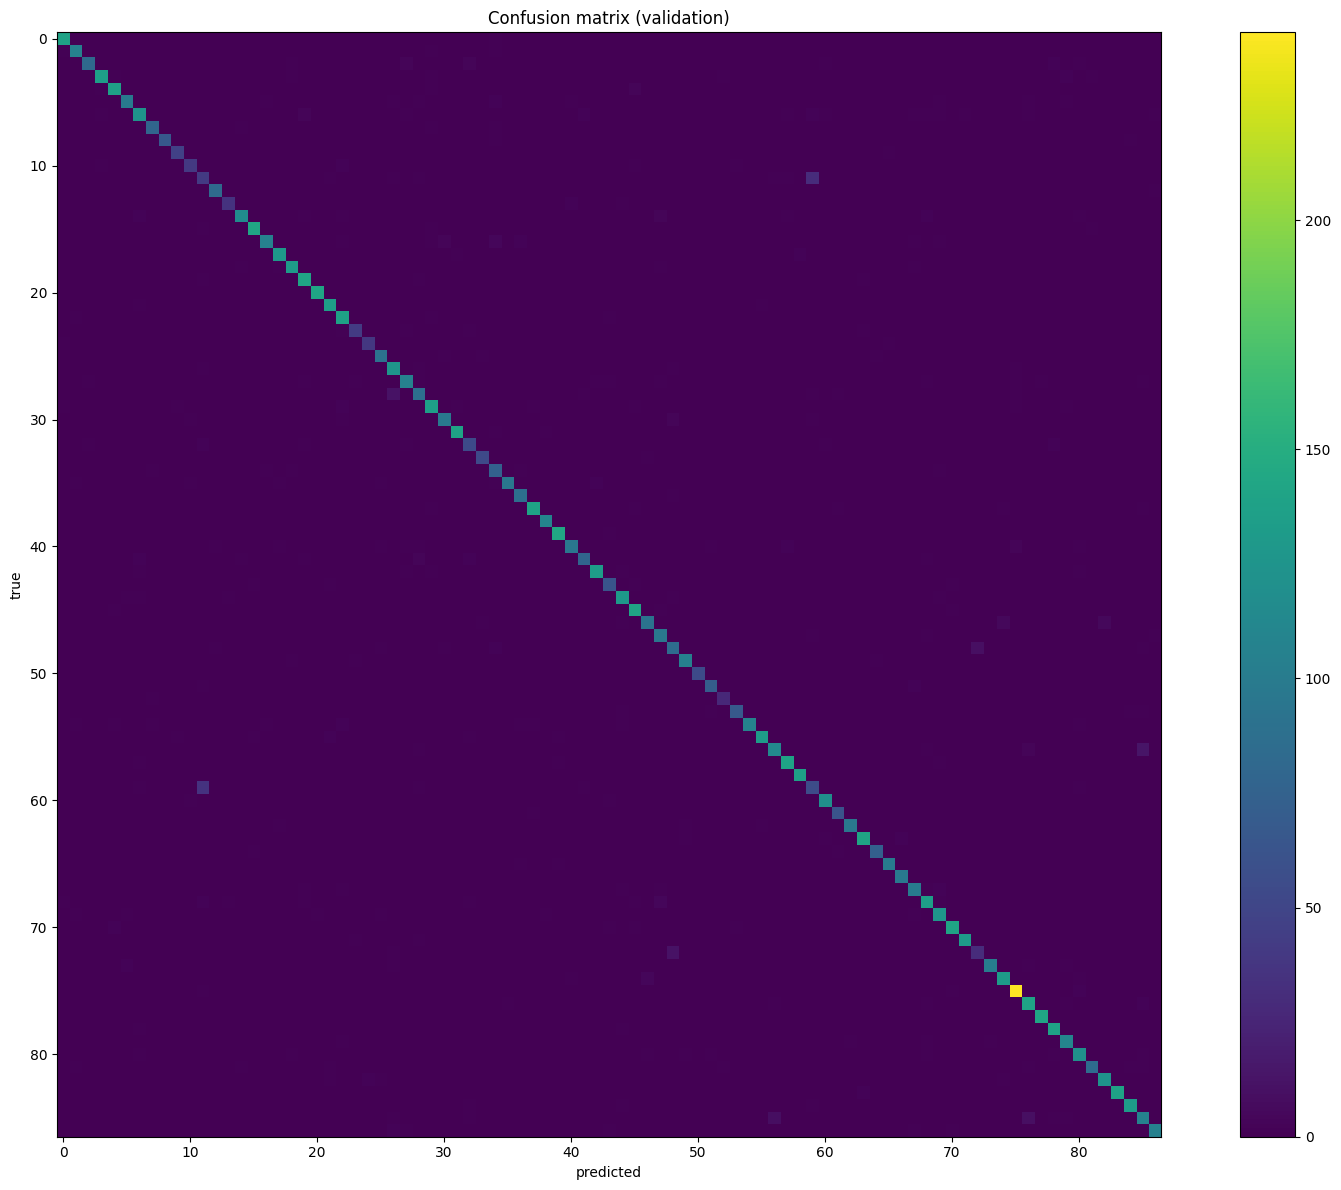

Saved confusion_matrix.png and confusion_matrix.csv


In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap="viridis")
ax.set_title("Confusion matrix (validation)")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
fig.colorbar(im)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=120)
plt.show()
print("Saved confusion_matrix.png and confusion_matrix.csv")


## ONNX export, opset 18, single graph (dynamo=False).

Exports the raw logits model - NOT softmax. The Java backend applies softmax
for the confidence gate. Keeping logits also preserves the option of
temperature scaling later for calibration. Batch axis is dynamic so the
 backend can send one image or a batch.

In [ ]:
model.eval()
ONNX_PATH = OUTPUT_DIR / "hardware_store_mobilenetv3.onnx"
dummy_input = torch.randn(1, 3, 224, 224, device=device).to(
    memory_format=torch.channels_last)

In [ ]:
TEST_DIR = "/content/images2test"

In [ ]:
!pip install onnx  onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 101.4 MB/s eta 0:00:00


In [ ]:
import onnx
import onnxruntime as ort

In [ ]:

torch.onnx.export(
    model,
    dummy_input,
    str(ONNX_PATH),
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    dynamo=False,
)

/tmp/ipykernel_717/3140377598.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
print(f"Exported {ONNX_PATH} ({ONNX_PATH.stat().st_size / 1e6:.1f} MB)")


Exported /content/training_output/hardware_store_mobilenetv3.onnx (17.2 MB)


In [ ]:
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)

In [ ]:
session = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
onnx_out = session.run(None, {"input": dummy_input.cpu().numpy()})[0]


In [ ]:
with torch.no_grad():
    torch_out = model(dummy_input).cpu().numpy()

In [ ]:
import copy

In [ ]:
# ONNX graph structural check
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)

In [ ]:
session = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])


In [ ]:
# CPU float32 copy of the model for a same-device reference
model_cpu = copy.deepcopy(model).to("cpu").to(memory_format=torch.contiguous_format)
model_cpu.eval()

In [ ]:
ref_input = torch.randn(8, 3, 224, 224)
with torch.no_grad():
    torch_cpu_out = model_cpu(ref_input).numpy()
onnx_out = session.run(None, {"input": ref_input.numpy()})[0]

In [ ]:

fidelity_diff = np.abs(onnx_out - torch_cpu_out).max()
print(f"Check 1 - CPU fidelity max abs diff: {fidelity_diff:.6e}")
assert fidelity_diff < 1e-2, "ONNX export is not faithful to the CPU model"


Check 1 - CPU fidelity max abs diff: 3.218651e-06


In [ ]:

# Check  prediction agreement over a batch
torch_preds = torch_cpu_out.argmax(axis=1)
onnx_preds = onnx_out.argmax(axis=1)
agreement = (torch_preds == onnx_preds).mean()
print(f"Check 2 - top-1 prediction agreement: {agreement * 100:.1f}%")
assert agreement == 1.0, "ONNX predictions disagree with PyTorch"

print("ONNX verification passed - export is faithful and prediction")

Check 2 - top-1 prediction agreement: 100.0%
ONNX verification passed - export is faithful and prediction


In [ ]:
# Copy all artifacts to Drive.

DRIVE_OUT = Path("/content/drive/MyDrive/hardware-store/training")
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

In [ ]:
for artifact in OUTPUT_DIR.iterdir():
    if artifact.is_file():
        shutil.copy(artifact, DRIVE_OUT / artifact.name)


In [ ]:
print(f"All artifacts copied to {DRIVE_OUT}")
for p in sorted(DRIVE_OUT.iterdir()):
    print(" -", p.name)

All artifacts copied to /content/drive/MyDrive/hardware-store/training
 - best_model.pt
 - confusion_matrix.csv
 - confusion_matrix.png
 - final_metrics.json
 - hardware_store_mobilenetv3.onnx
 - history.json
 - idx_to_class.json
 - per_class_metrics.csv
 - training_curves.png
